In [ ]:
import json


def open_json_file(file_path):
    result = json.load(open(file_path))

    metric = result["metric"]
    avg_metric = result["metric_avg"]

    for k, v in avg_metric.items():
        print(f"{k}: {v['mae']}")



In [ ]:
open_json_file("comparison_synth_.json")

In [ ]:
from train_fusion.dataloader import MiddleburyDataset
import os
import matplotlib.pyplot as plt
dataset = MiddleburyDataset("data/middlebury/")
print(os.listdir("data/middlebury/"))
print(len(dataset))
for x in dataset[0]:
    plt.imshow(x.permute(1, 2, 0) / 255, vmax=1)
    plt.colorbar()
    plt.show()
    

In [256]:
od_json = json.load(open("object_detection_loss_dict_day.json"))

In [17]:
loss_metric = ['loss', 'coord_loss', 'object_loss', 'no_object_loss', 'missing_object_loss'] # 'boxes', 

In [184]:
avg_loss = {}
for key in od_json.keys():
    if key == "box_gt":
        continue
    avg_loss[key] = {}
    for metric in loss_metric:
        avg_loss[key][metric] = sum(od_json[key][metric]) / len(od_json[key][metric])

In [185]:
json.dump(avg_loss, open("object_detection_avg_loss.json", "w"), indent=4)

In [26]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import os
from PIL import Image
import xml.etree.ElementTree as ET
class MultiSpectralDataset(Dataset):
    def __init__(self, data_root, transform=None):
        self.data_root = data_root
        self.visible_dir = os.path.join(data_root, 'visible')
        self.lwir_dir = os.path.join(data_root, 'lwir')
        self.label_dir = os.path.join(data_root, 'label')
        self.transform = transform
        self.sample_ids = self._get_valid_samples()

    def _get_valid_samples(self):
        sample_ids = []
        for filename in os.listdir(self.label_dir):
            if not filename.endswith('.xml'):
                continue
            filepath = os.path.join(self.label_dir, filename)
            tree = ET.parse(filepath)
            root = tree.getroot()
            objects = root.findall('object')
            if len(objects) > 0:
                sample_id = os.path.splitext(filename)[0]
                sample_ids.append(sample_id)
        return sample_ids

    def __len__(self):
        return len(self.sample_ids)

    def _parse_label(self, xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        boxes = []
        for obj in root.findall('object'):
            bndbox = obj.find('bndbox')
            x = float(bndbox.find('x').text)
            y = float(bndbox.find('y').text)
            w = float(bndbox.find('w').text)
            h = float(bndbox.find('h').text)
            boxes.append([x, y, w, h])
        return boxes

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        visible_img_path = os.path.join(self.visible_dir, f"{sample_id}.jpg")
        lwir_img_path = os.path.join(self.lwir_dir, f"{sample_id}.jpg")
        label_path = os.path.join(self.label_dir, f"{sample_id}.xml")

        visible_img = Image.open(visible_img_path).convert('RGB')
        lwir_img = Image.open(lwir_img_path).convert('L')

        boxes = self._parse_label(label_path)

        if self.transform:
            visible_img = self.transform(visible_img)
            lwir_img = self.transform(lwir_img)
        
        boxes = torch.tensor(boxes, dtype=torch.float32)

        return visible_img, lwir_img, boxes
dtdataset = MultiSpectralDataset("data/pedestrian/sample")

In [22]:
print(avg_loss)
json.dump(avg_loss, open("object_detection_loss_dict_avg.json", "w"))

{'ngb': {'loss': 10.079245749583913, 'coord_loss': 1.9745268374681473, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.2066115702479339}, 'rgbsum': {'loss': 10.36676520700297, 'coord_loss': 2.0105431123582784, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.3140495867768595}, 'hsv': {'loss': 8.586723044391507, 'coord_loss': 1.6611462638767298, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.2809917355371901}, 'herrera': {'loss': 5.410706491029563, 'coord_loss': 0.8939059994676534, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.9411764705882353}, 'adt': {'loss': 10.163783067414741, 'coord_loss': 1.99746250480163, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.17647058823529413}, 'basian': {'loss': 10.14554696273403, 'coord_loss': 1.9770085452860142, 'object_loss': 0.0, 'no_object_loss': 0.0, 'missing_object_loss': 0.2605042016806723}, 'vgg': {'loss': 10.347736216392837, 'coord_loss': 2.

In [221]:
import torch
from sklearn.metrics import precision_recall_curve, average_precision_score
from torchvision.ops import box_iou, box_convert

def calculate_map(pred_boxes, gt_boxes, iou_threshold=0.5):
    """
    pred_boxes: [n_pred, 4] Tensor or array-like -> 예측 박스 (x_min, y_min, w, h)
    gt_boxes: [n_gt, 4] Tensor or array-like -> 실제 박스 (x_min, y_min, w, h)
    """
    pred_boxes = torch.as_tensor(pred_boxes).reshape(-1, 4)
    gt_boxes = torch.as_tensor(gt_boxes).reshape(-1, 4)
    
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return 1.0  # 예측과 실제 박스 모두 없는 경우
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0  # 예측 또는 실제 박스가 없는 경우

    # 변환: [x_min, y_min, w, h] -> [x1, y1, x2, y2]
    pred_boxes = box_convert(pred_boxes, 'xywh', 'xyxy')
    gt_boxes = box_convert(gt_boxes, 'xywh', 'xyxy')
    
    # 모든 예측에 대해 IoU 계산
    ious = box_iou(pred_boxes, gt_boxes)  # [n_pred, n_gt]
    
    # 매칭
    matched = set()
    scores = []
    labels = []
    
    for i in range(len(pred_boxes)):
        max_iou = ious[i].max().item()
        j = ious[i].argmax().item()
        if max_iou >= iou_threshold and j not in matched:
            matched.add(j)
            labels.append(1)  # True Positive
        else:
            labels.append(0)  # False Positive
        scores.append(max_iou)
    
    if not scores:
        return 0.0  # 예측이 없을 경우 AP는 0

    # Precision-Recall 계산
    precision, recall, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    
    return ap

def calculate_precision_recall(pred_boxes, gt_boxes, iou_threshold=0.5):
    pred_boxes = torch.as_tensor(pred_boxes).reshape(-1, 4)
    gt_boxes = torch.as_tensor(gt_boxes).reshape(-1, 4)
    
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return 1.0, 1.0
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0, 0.0

    pred_boxes = box_convert(pred_boxes, 'xywh', 'xyxy')
    gt_boxes = box_convert(gt_boxes, 'xywh', 'xyxy')
    
    ious = box_iou(pred_boxes, gt_boxes)
    
    matched = set()
    true_positives = 0
    false_positives = 0
    
    for i in range(len(pred_boxes)):
        max_iou, j = ious[i].max(0)
        max_iou = max_iou.item()
        j = j.item()
        if max_iou >= iou_threshold and j not in matched:
            true_positives += 1
            matched.add(j)
        else:
            false_positives += 1
    
    false_negatives = len(gt_boxes) - len(matched)
    
    precision = true_positives / (true_positives + false_positives + 1e-6)
    recall = true_positives / (true_positives + false_negatives + 1e-6)
    
    return precision, recall

def calculate_average_iou(pred_boxes, gt_boxes, iou_threshold=0.5):
    pred_boxes = torch.as_tensor(pred_boxes).reshape(-1, 4)
    gt_boxes = torch.as_tensor(gt_boxes).reshape(-1, 4)
    
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return 0.0
    
    pred_boxes = box_convert(pred_boxes, 'xywh', 'xyxy')
    gt_boxes = box_convert(gt_boxes, 'xywh', 'xyxy')
    
    ious = box_iou(pred_boxes, gt_boxes)
    max_ious, _ = ious.max(dim=1)
    average_iou = max_ious.mean().item()
    
    return average_iou

def calculate_f1_score(pred_boxes, gt_boxes, iou_threshold=0.5):
    precision, recall = calculate_precision_recall(pred_boxes, gt_boxes, iou_threshold)
    if precision + recall == 0:
        return 0.0
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def calculate_custom_metrics(pred_boxes, gt_boxes, iou_threshold=0.5):
    pred_boxes = torch.as_tensor(pred_boxes).reshape(-1, 4)
    gt_boxes = torch.as_tensor(gt_boxes).reshape(-1, 4)
    
    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return {'true_positives': 0, 'false_positives': 0, 'false_negatives': 0}
    if len(pred_boxes) == 0:
        return {'true_positives': 0, 'false_positives': 0, 'false_negatives': len(gt_boxes)}
    if len(gt_boxes) == 0:
        return {'true_positives': 0, 'false_positives': len(pred_boxes), 'false_negatives': 0}

    pred_boxes = box_convert(pred_boxes, 'xywh', 'xyxy')
    gt_boxes = box_convert(gt_boxes, 'xywh', 'xyxy')
    
    ious = box_iou(pred_boxes, gt_boxes)
    
    matched = set()
    true_positives = 0
    false_positives = 0
    
    for i in range(len(pred_boxes)):
        max_iou, j = ious[i].max(0)
        max_iou = max_iou.item()
        j = j.item()
        if max_iou >= iou_threshold and j not in matched:
            true_positives += 1
            matched.add(j)
        else:
            false_positives += 1
    
    false_negatives = len(gt_boxes) - len(matched)
    
    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }


(512, 640, 3)
tensor(374.)
tensor(491.)


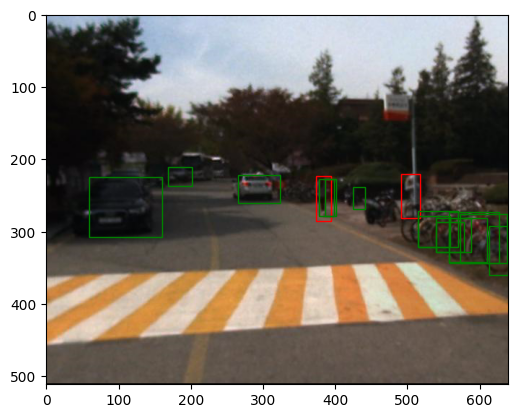

In [231]:
image = np.array(dtdataset[0][0])
plt.imshow(image)
print(image.shape)
for box in dtdataset[0][2]:

    x, y, w, h = box
    print(x)
    
   


    plt.gca().add_patch(plt.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none'))
for box in box_pred[0]:

    x, y, w, h = box
    if w < 2 or h < 2:
        sc = 50
        x = x * sc * 640 / 512
        y = y * sc
        w = w * sc  * 640 / 512
        h = h * sc
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, linewidth=1, edgecolor='g', facecolor='none'))
plt.show()

In [258]:
import numpy as np
import matplotlib.pyplot as plt
print(len(box_pred))

eval_dict = {}
for k in od_json.keys():
    if k == "box_gt":
        continue
    eval_dict[k] = {}
    eval_dict[k]['map'] = []
    eval_dict[k]['average_iou'] = []
    eval_dict[k]['f1_score'] = []
    eval_dict[k]['custom_metrics'] = []
    eval_dict[k]['precision'] = []
    eval_dict[k]['recall'] = []
    for i in range(len(od_json[k]['boxes'])):
        #gt_boxes = dtdataset[i][2]
        gt_boxes= pseudo_ground_truth[i]
        box_pred_cur = od_json[k]['boxes'][i]
        pred_boxes = torch.tensor(box_pred_cur)
        
        # image = np.array(dtdataset[i][0])
        # plt.imshow(image)
        # for box in pred_boxes:
        #     x, y, w, h = box
        #     plt.gca().add_patch(plt.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none'))
        # plt.show()

        eval_dict[k]['map'].append(calculate_map(pred_boxes, gt_boxes))
        eval_dict[k]['average_iou'].append(calculate_average_iou(pred_boxes, gt_boxes))
        eval_dict[k]['f1_score'].append(calculate_f1_score(pred_boxes, gt_boxes))
        eval_dict[k]['custom_metrics'].append(calculate_custom_metrics(pred_boxes, gt_boxes))
        precision, recall = calculate_precision_recall(pred_boxes, gt_boxes)
        eval_dict[k]['precision'].append(precision)
        eval_dict[k]['recall'].append(recall)



200


/home/wlssud0701/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wlssud0701/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wlssud0701/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wlssud0701/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wlssud0701/miniconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1030: UserWarning: No positive class found in y_true, recall is set to o

In [259]:
json.dump(eval_dict, open("object_detection_eval_dict_day.json", "w"), indent=4)

In [261]:
pd.DataFrame(eval_avg_dict).to_csv("object_detection_eval_avg_day.csv")

rgb: map -> 0.7713888888888889
rgb: average_iou -> 0.5171795530244708
rgb: precision -> 0.653833015914128
rgb: recall -> 0.6616663578613307
rgb: f1_score -> 0.6449917665906204


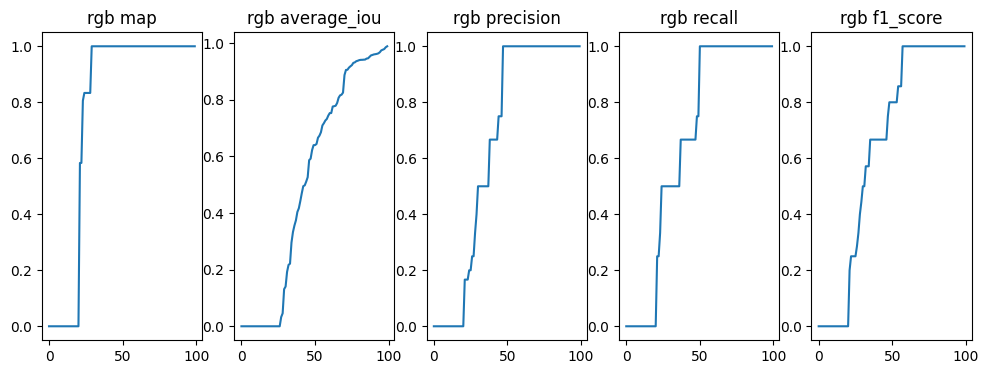

nir: map -> 0.6908333333333333
nir: average_iou -> 0.46313991557806733
nir: precision -> 0.5973330010891676
nir: recall -> 0.5518330737307475
nir: f1_score -> 0.5502457778171446


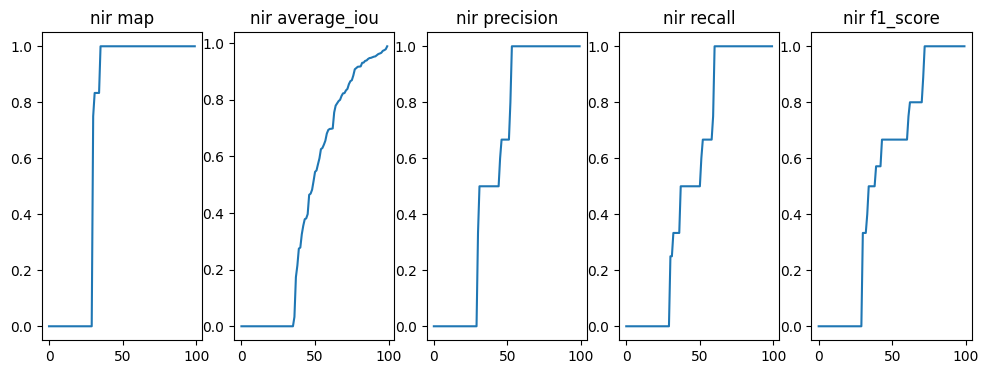

ngb: map -> 0.7808333333333333
ngb: average_iou -> 0.5212919728830456
ngb: precision -> 0.6663567962631477
ngb: recall -> 0.6524996923752252
ngb: f1_score -> 0.6407493427609131


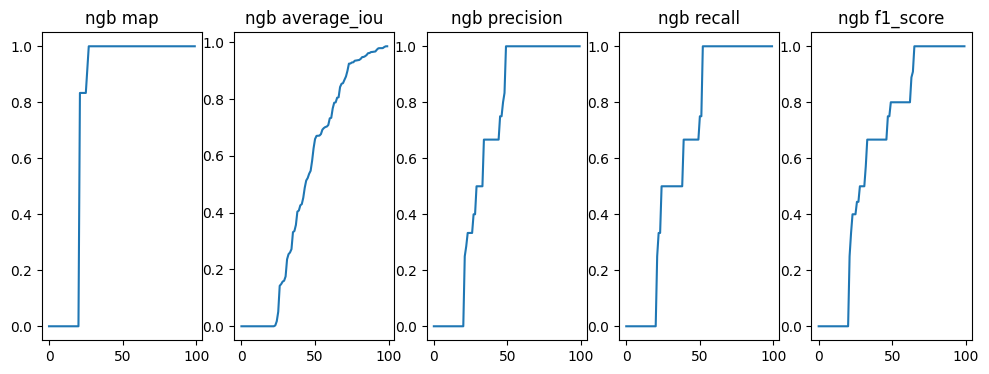

rgbsum: map -> 0.777763888888889
rgbsum: average_iou -> 0.5196062881126999
rgbsum: precision -> 0.6654087658850314
rgbsum: recall -> 0.6699996884168926
rgbsum: f1_score -> 0.6544826078052093


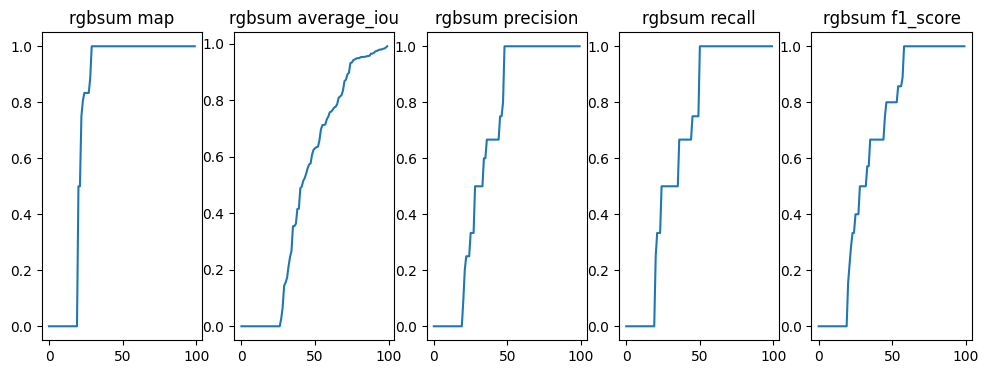

hsv: map -> 0.7335972222222223
hsv: average_iou -> 0.4958323705196381
hsv: precision -> 0.6426022418297603
hsv: recall -> 0.6249997209168666
hsv: f1_score -> 0.618960039006734


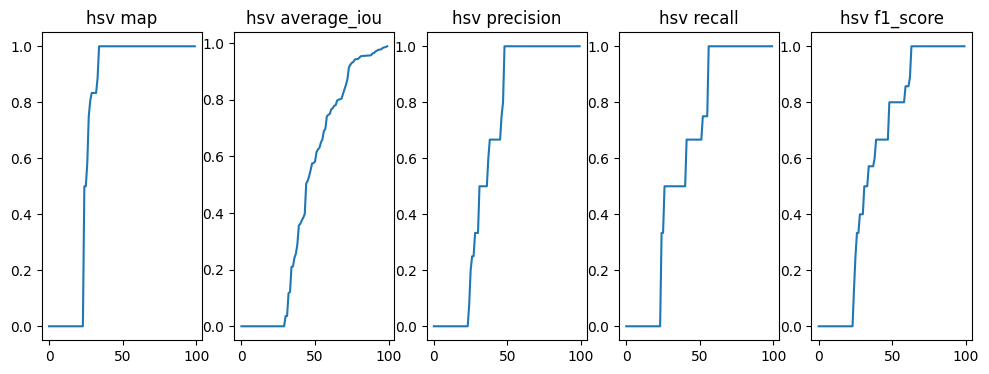

dvn: map -> 0.5661666666666666
dvn: average_iou -> 0.37236518912017347
dvn: precision -> 0.5038330795807608
dvn: recall -> 0.4846664470112741
dvn: f1_score -> 0.4780156620132557


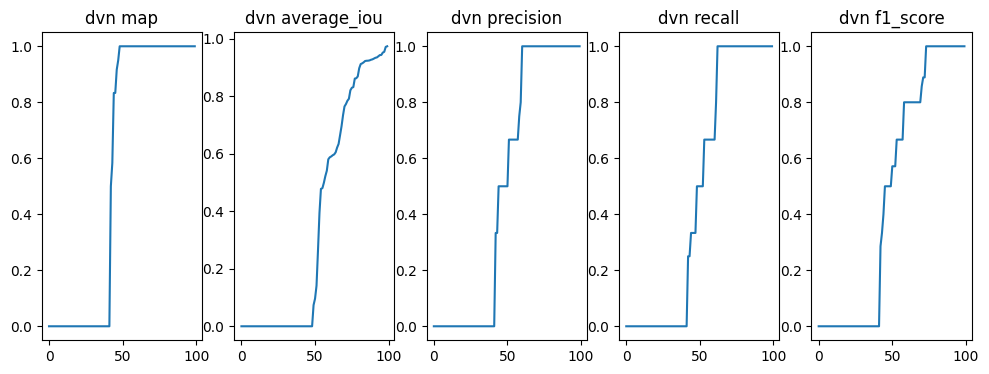

basian: map -> 0.7658888888888891
basian: average_iou -> 0.5166075091063976
basian: precision -> 0.6512421185100077
basian: recall -> 0.6666663566113362
basian: f1_score -> 0.6465302346029712


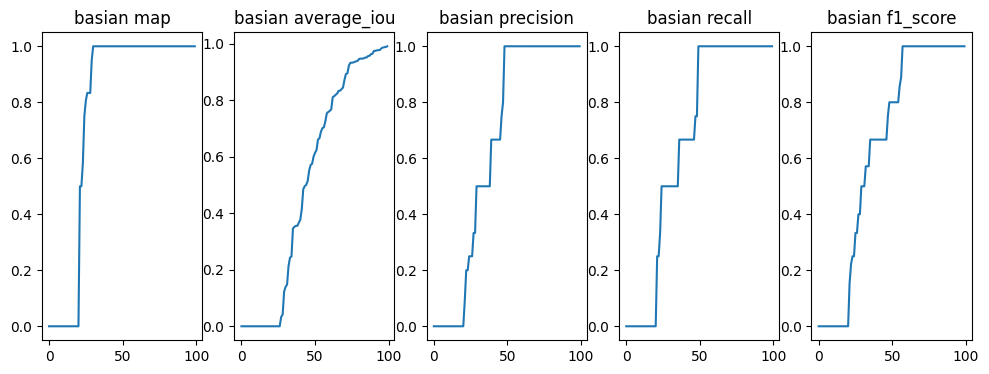

adt: map -> 0.7491
adt: average_iou -> 0.4960439150594175
adt: precision -> 0.6365949164275282
adt: recall -> 0.6299997171668685
adt: f1_score -> 0.6152255547359551


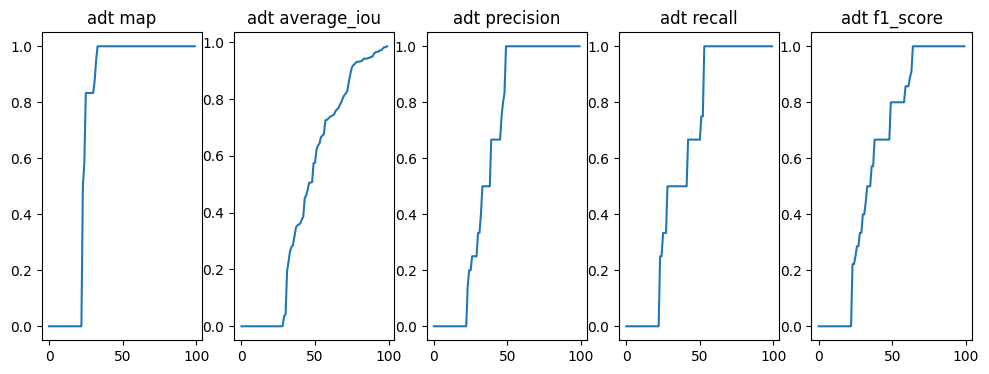

vgg: map -> 0.7528333333333335
vgg: average_iou -> 0.4803124105138704
vgg: precision -> 0.596277499662857
vgg: recall -> 0.6333330293891062
vgg: f1_score -> 0.5943215319145764


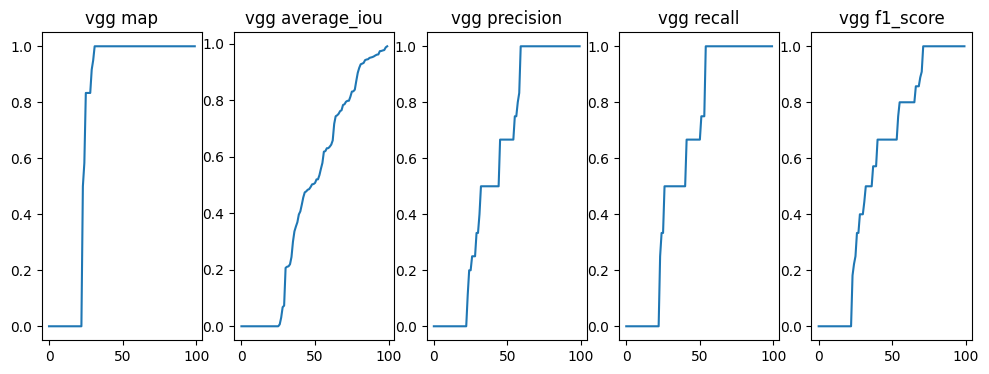

herrera: map -> 0.720875
herrera: average_iou -> 0.49589309457689523
herrera: precision -> 0.6339996565891782
herrera: recall -> 0.5996663949279755
herrera: f1_score -> 0.5943806796712527


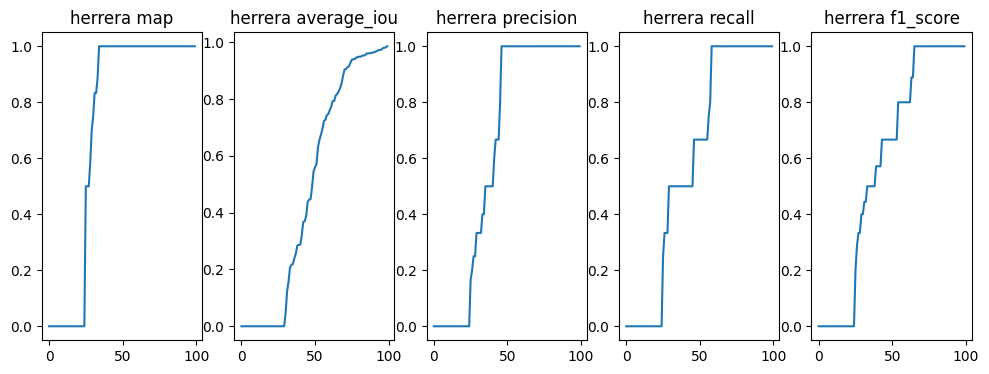

fusion[sceneflow]: map -> 0.6558333333333333
fusion[sceneflow]: average_iou -> 0.4242092635948211
fusion[sceneflow]: precision -> 0.5533330696668743
fusion[sceneflow]: recall -> 0.5359997813001458
fusion[sceneflow]: f1_score -> 0.5248648696452576


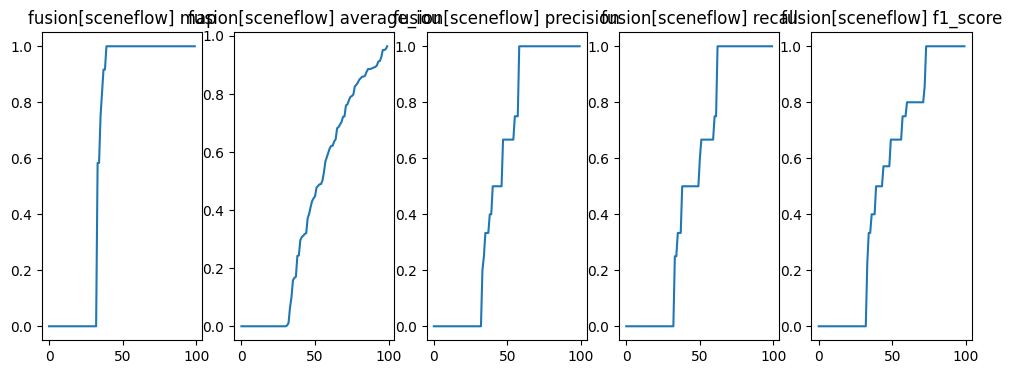

fusion[eth3d]: map -> 0.7442083333333334
fusion[eth3d]: average_iou -> 0.44165758343413475
fusion[eth3d]: precision -> 0.5909521003125789
fusion[eth3d]: recall -> 0.5738330991640462
fusion[eth3d]: f1_score -> 0.5654052516084982


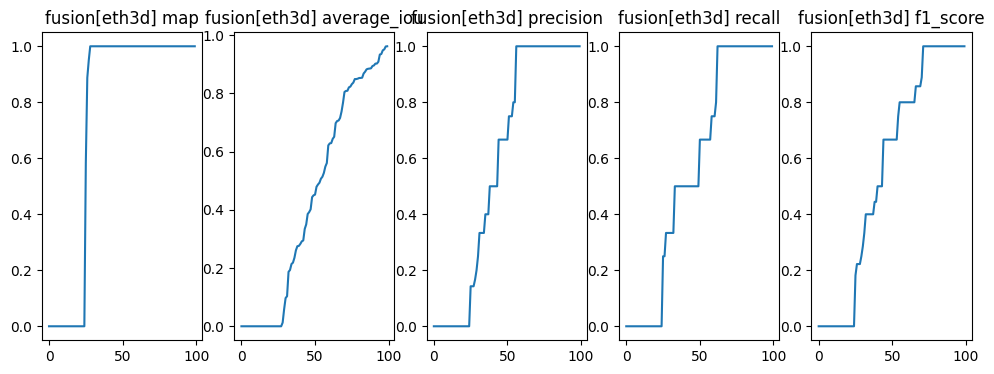

fusion[middlebury]: map -> 0.7491555555555556
fusion[middlebury]: average_iou -> 0.4598005518969148
fusion[middlebury]: precision -> 0.6063449475018039
fusion[middlebury]: recall -> 0.6041664159862807
fusion[middlebury]: f1_score -> 0.5874160616725085


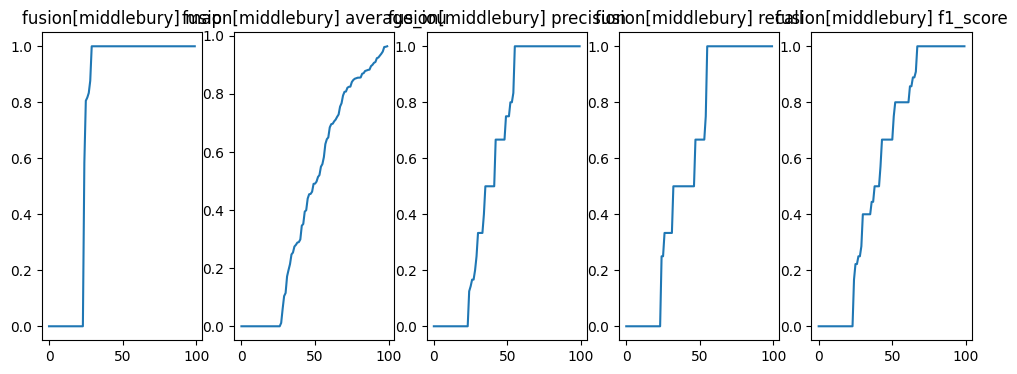

In [260]:
eval_avg_dict = {}
for k in od_json.keys():
    if k == "box_gt":
        continue
    plt.figure(figsize=(12, 4))
    eval_avg_dict[k] = {}
    for metric in metrics:
        print(f"{k}: {metric} -> {sum(eval_dict[k][metric]) / len(eval_dict[k][metric])}")
        eval_avg_dict[k][metric] = sum(eval_dict[k][metric]) / len(eval_dict[k][metric])
        plt.subplot(1, 5, metrics.index(metric) + 1)
        values = list(eval_dict[k][metric])
        values.sort()
        plt.plot(range(len(eval_dict[k][metric])), values)
        plt.title(f"{k} {metric}")
    plt.show()
json.dump(eval_avg_dict, open("object_detection_eval_avg_dict_day.json", "w"), indent=4)
        

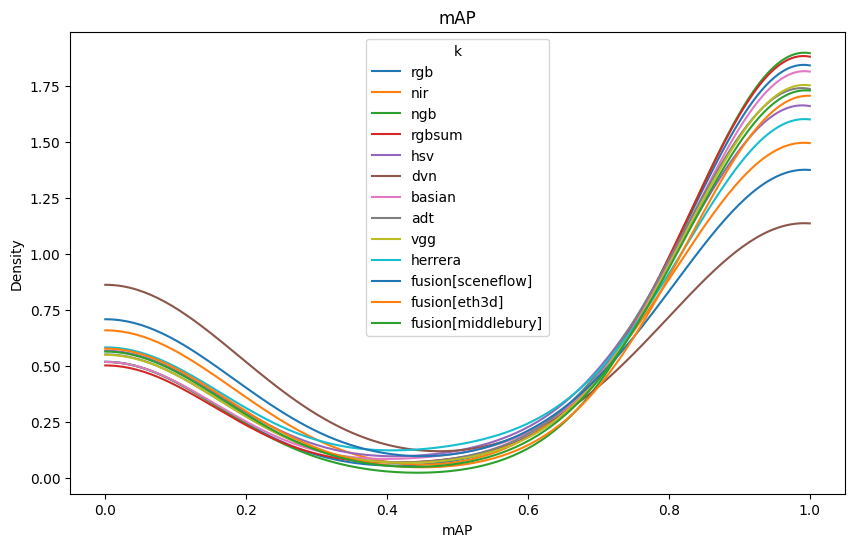

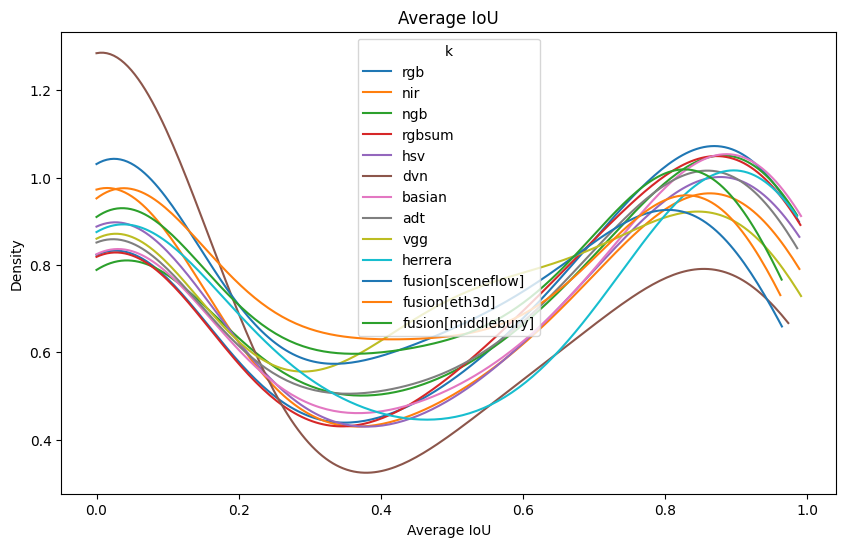

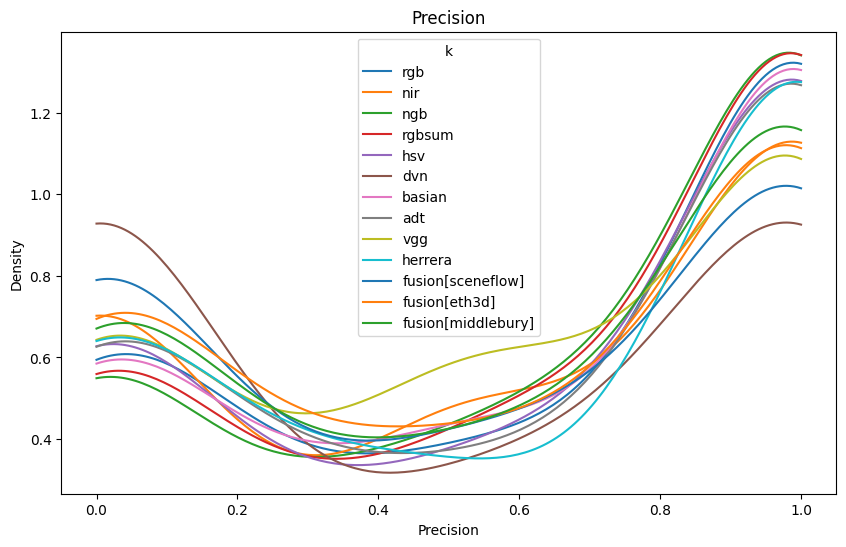

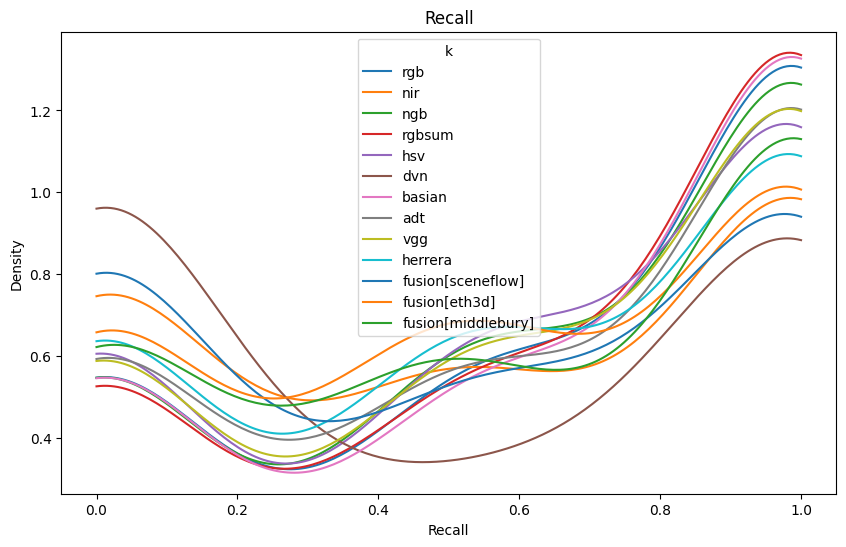

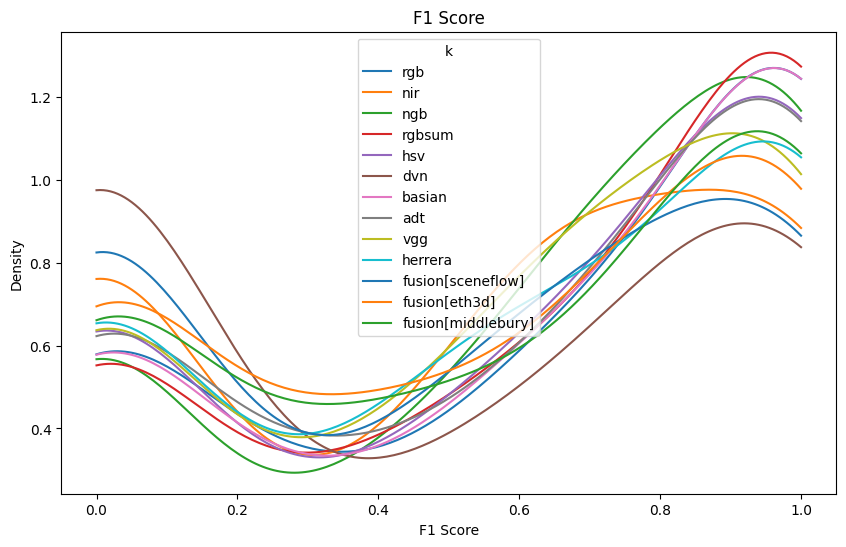

In [262]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 지표 목록과 제목 설정
metrics = ['map', 'average_iou', 'precision','recall', 'f1_score']
metric_titles = {'map': 'mAP', 'average_iou': 'Average IoU', 'precision':'Precision','recall':'Recall', 'f1_score': 'F1 Score'}

# 각 지표에 대해 그래프 그리기
for metric in metrics:
    plt.figure(figsize=(10, 6))
    for k in eval_dict.keys():
        data = eval_dict[k][metric]
        density = gaussian_kde(data)
        xs = np.linspace(min(data), max(data), 200)
        plt.plot(xs, density(xs), label=str(k))
    plt.title(metric_titles[metric])
    plt.xlabel(metric_titles[metric])
    plt.ylabel('Density')
    plt.legend(title='k')
    plt.show()

In [257]:
from sklearn.cluster import DBSCAN

n = len(od_json['rgb']['boxes'])
keys = list(od_json.keys())
keys = [x for x in keys if x != "box_gt"]
K = len(keys)
def cluster_boxes(boxes, eps=50, min_samples=2):
    if not boxes:
        return []
    # 박스의 중심점 사용
    centers = np.array([[box[0] + box[2]/2, box[1] + box[3]/2] for box in boxes])
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(centers)
    labels = clustering.labels_
    unique_labels = set(labels)
    gt_boxes = []
    for label in unique_labels:
        if label == -1:
            continue  # 노이즈
        cluster = [boxes[i] for i in range(len(boxes)) if labels[i] == label]
        # 클러스터의 평균 박스 사용
        avg_box = np.mean(cluster, axis=0)
        gt_boxes.append(avg_box.tolist())
    return gt_boxes

pseudo_ground_truth = []
for data_idx in range(n):
    combined_boxes = []
    for model_idx in range(K):
        combined_boxes.extend(od_json[keys[model_idx]]['boxes'][data_idx])
    # 클러스터링 적용
    gt_boxes = cluster_boxes(combined_boxes, eps=50, min_samples=2)
    pseudo_ground_truth.append(gt_boxes)

In [242]:
print(len(pseudo_ground_truth))

100


In [229]:
eval_dict = {}

for label in ["synth","real_day_rgb","real_night","real_indoor"]:
    output = json.load(open(f"comparison_{label}_.json"))["metric_avg"]
    for k in output.keys():
        if len(k.split("][")) < 2:
            continue
        if not k in eval_dict.keys():
            eval_dict[k] = {}
        eval_dict[k][label] = output[k]["mae"]

import pandas as pd
df = pd.DataFrame(eval_dict)
print(df)
df.to_csv("comparison.csv")

              [add][Fusion]  [add][Origin]  [add][Mixed]  [add][Nir]  \
synth              7.784076       5.715617      4.454435    7.356530   
real_day_rgb       3.757399       4.175956      3.979580    3.907833   
real_night         3.875988       4.471582      3.692758    3.541898   
real_indoor        0.738832       0.771712      0.681234    0.698652   

              [bAFF][Fusion]  [bAFF][Origin]  [bAFF][Mixed]  [bAFF][Nir]  \
synth               6.604870        4.248694       3.929743     5.557230   
real_day_rgb        3.742883        4.130001       3.983213     4.075554   
real_night          4.158620        4.301832       3.619139     3.485902   
real_indoor         0.748807        0.765687       0.681026     0.690961   

              [AFF][Fusion]  [AFF][Origin]  [AFF][Mixed]  [AFF][Nir]  
synth              4.332685       4.312782      3.198168    3.955119  
real_day_rgb       3.761734       4.183467      4.007934    3.996773  
real_night         3.931461       4.305299   